In [8]:
import numpy as py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [37]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()

In [39]:
california

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [41]:
print(california.data.shape)
print(california.target.shape)

(20640, 8)
(20640,)


In [42]:
california.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [53]:
california_df = pd.DataFrame(california.data, columns = california.feature_names)
california_df['MedHouseValue'] = pd.Series(california.target)
california_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [54]:
california_df.describe()
'''The describe() method (commonly found in libraries like pandas and PySpark) is a primary 
tool for performing initial exploratory data analysis (EDA). It generates a descriptive statistics
summary of a dataset, providing key insights into the central tendency, dispersion, and shape of 
the data's distribution. '''

"The describe() method (commonly found in libraries like pandas and PySpark) is a primary \ntool for performing initial exploratory data analysis (EDA). It generates a descriptive statistics\nsummary of a dataset, providing key insights into the central tendency, dispersion, and shape of \nthe data's distribution. "

In [55]:
sample_df = california_df.sample(frac=0.1, random_state=17)
print(sample_df)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
18403  5.4741      24.0  6.587799   1.060181      4017.0  3.311624     37.24   
13405  1.9583       7.0  5.362805   1.442073      1064.0  3.243902     34.10   
9539   2.6058      40.0  3.885714   0.914286       785.0  4.485714     37.39   
8668   4.5817      30.0  4.146135   1.108696      1526.0  1.842995     33.82   
9019   8.0137       9.0  7.734673   1.041211     12873.0  3.274739     34.16   
...       ...       ...       ...        ...         ...       ...       ...   
19279  1.9458      26.0  4.709677   1.020161       937.0  3.778226     38.42   
12378  1.3801      25.0  4.737500   1.725000       604.0  2.516667     33.78   
16068  3.7361      48.0  5.754617   1.105541      1041.0  2.746702     37.75   
16563  5.0176      19.0  6.061538   0.956410      1264.0  3.241026     37.77   
12071  5.2898      25.0  6.722008   1.028958      3240.0  3.127413     33.86   

       Longitude  MedHouseValue  
18403

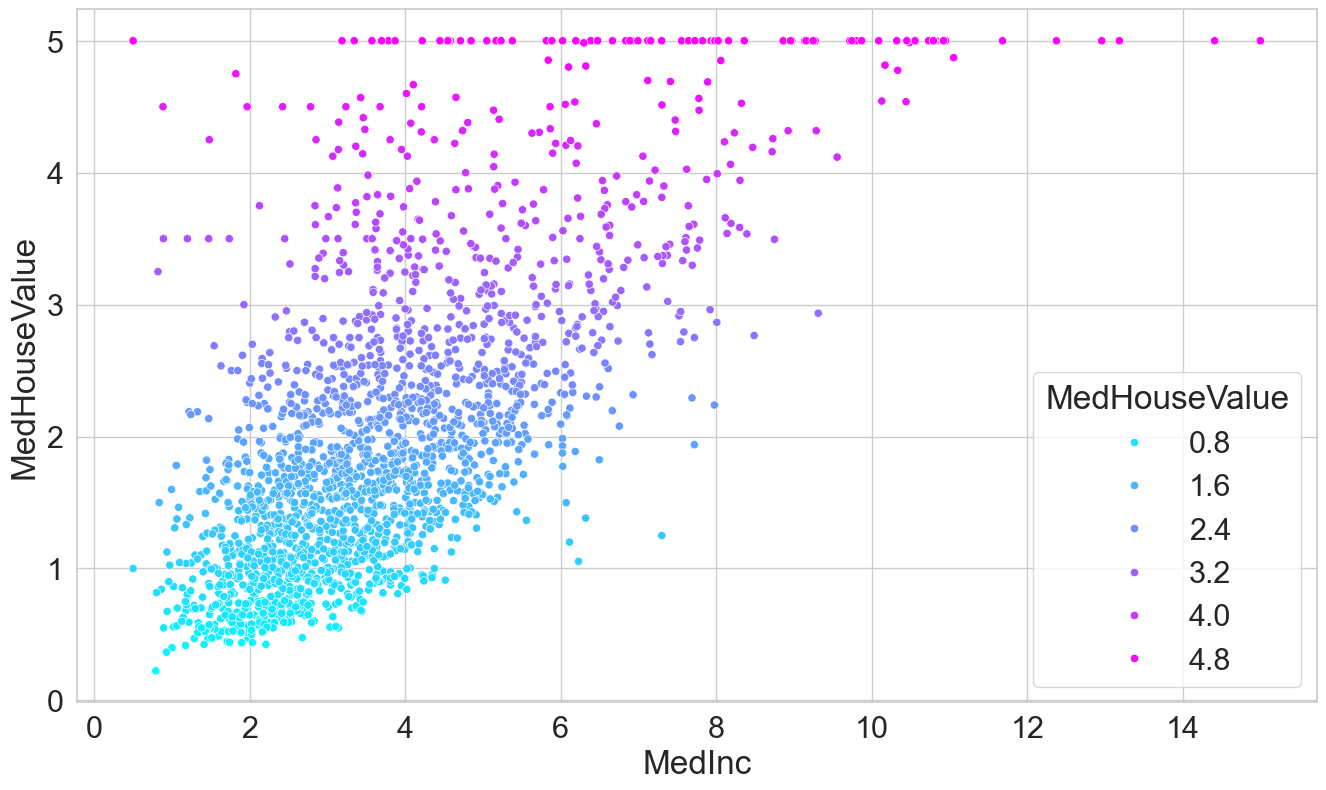

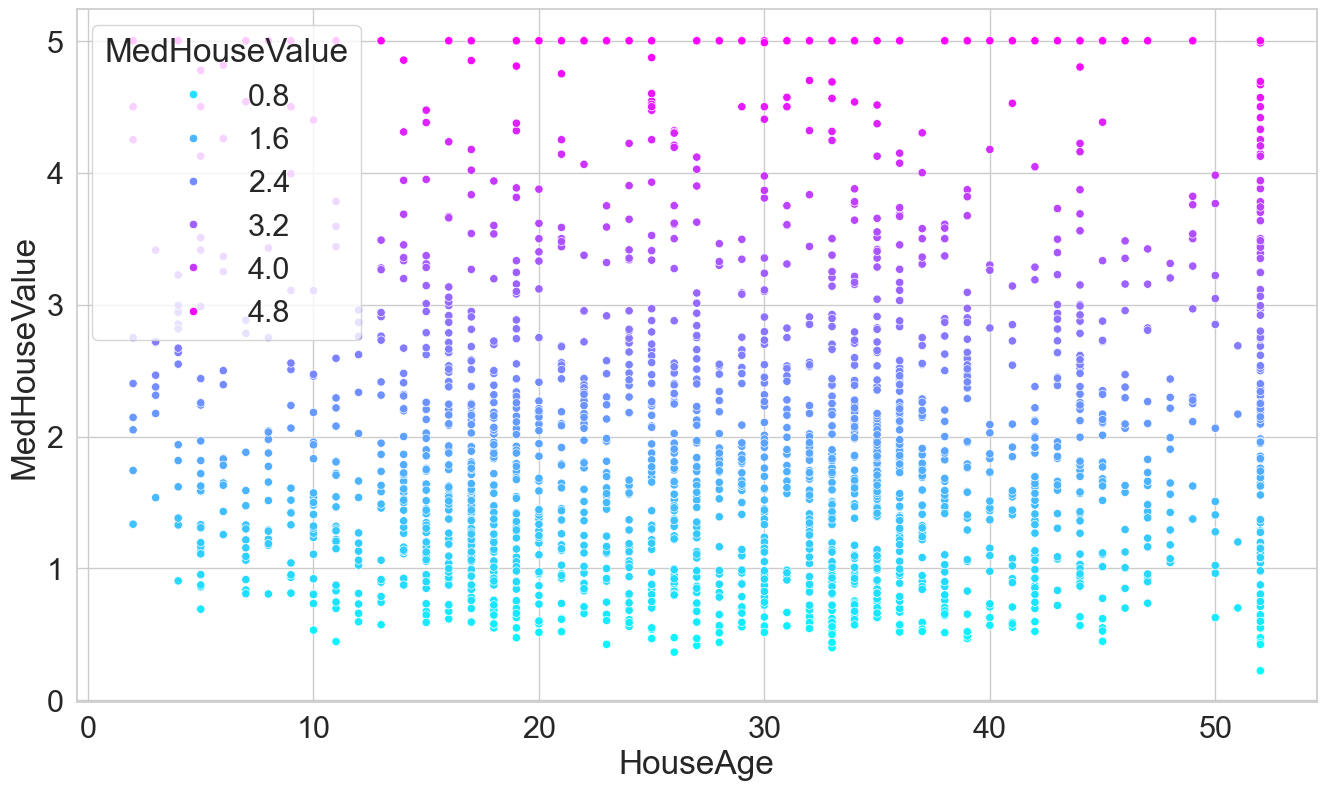

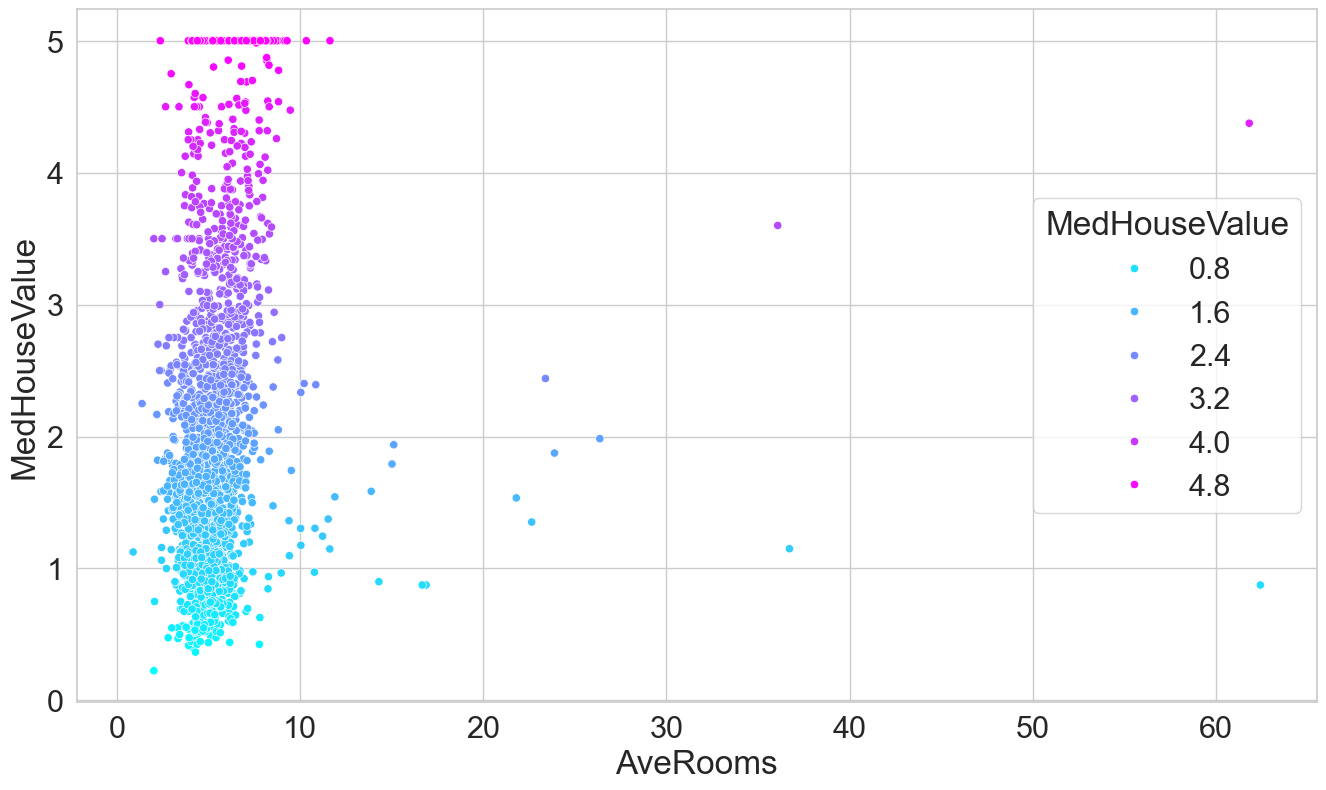

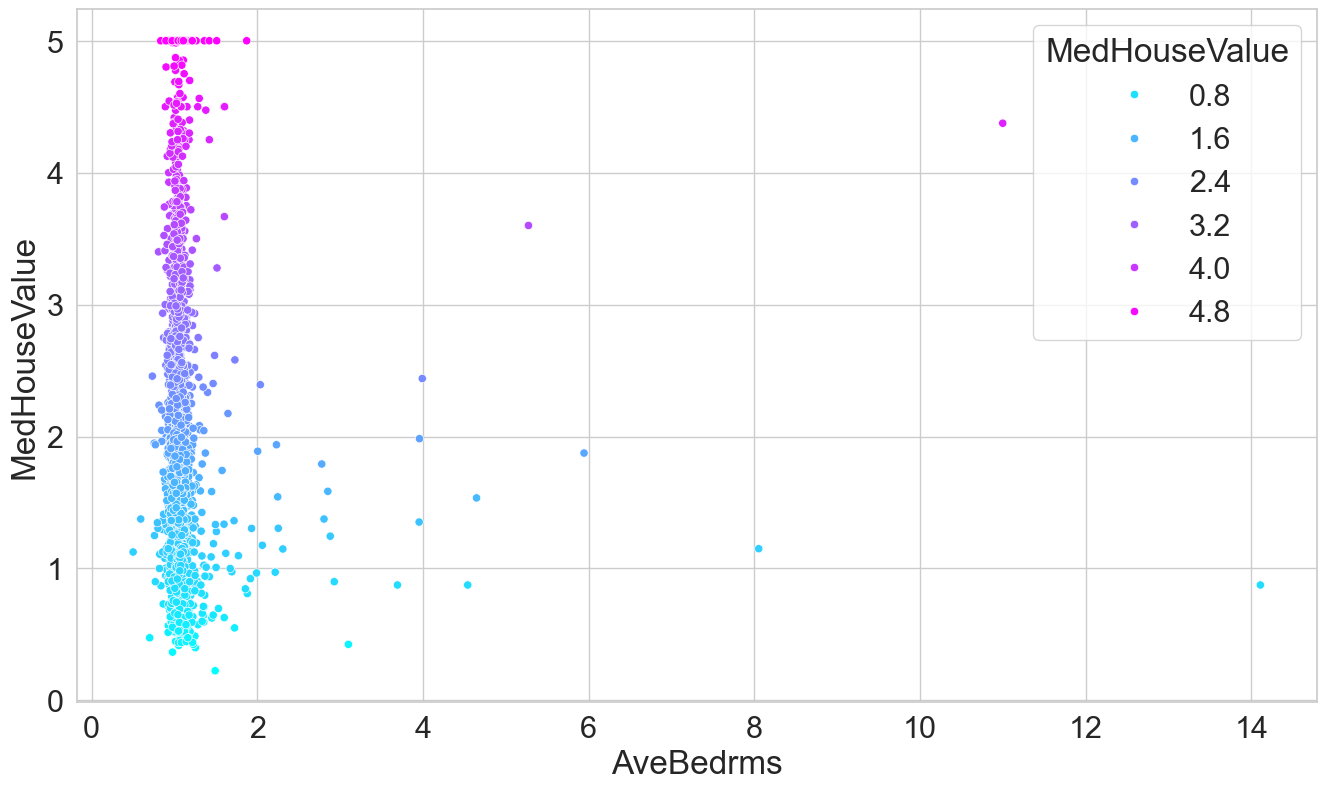

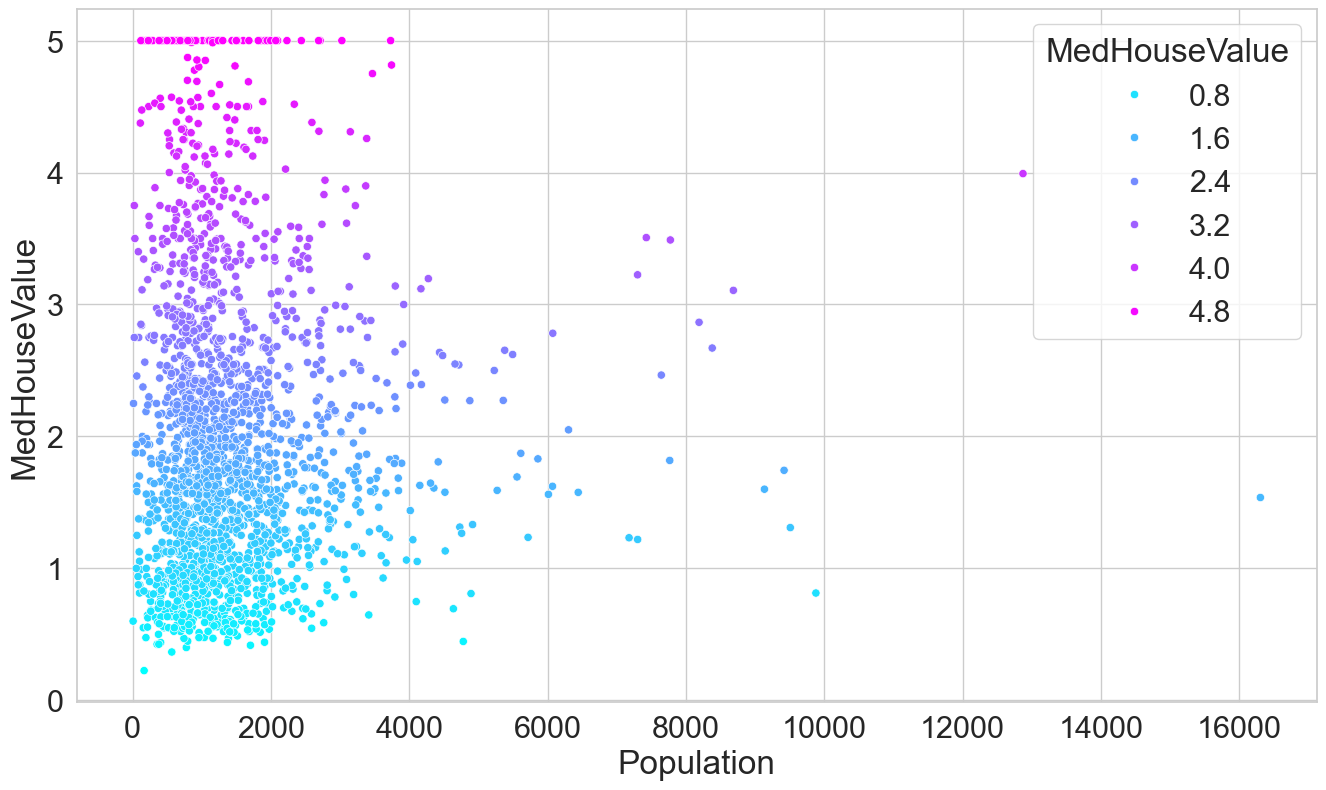

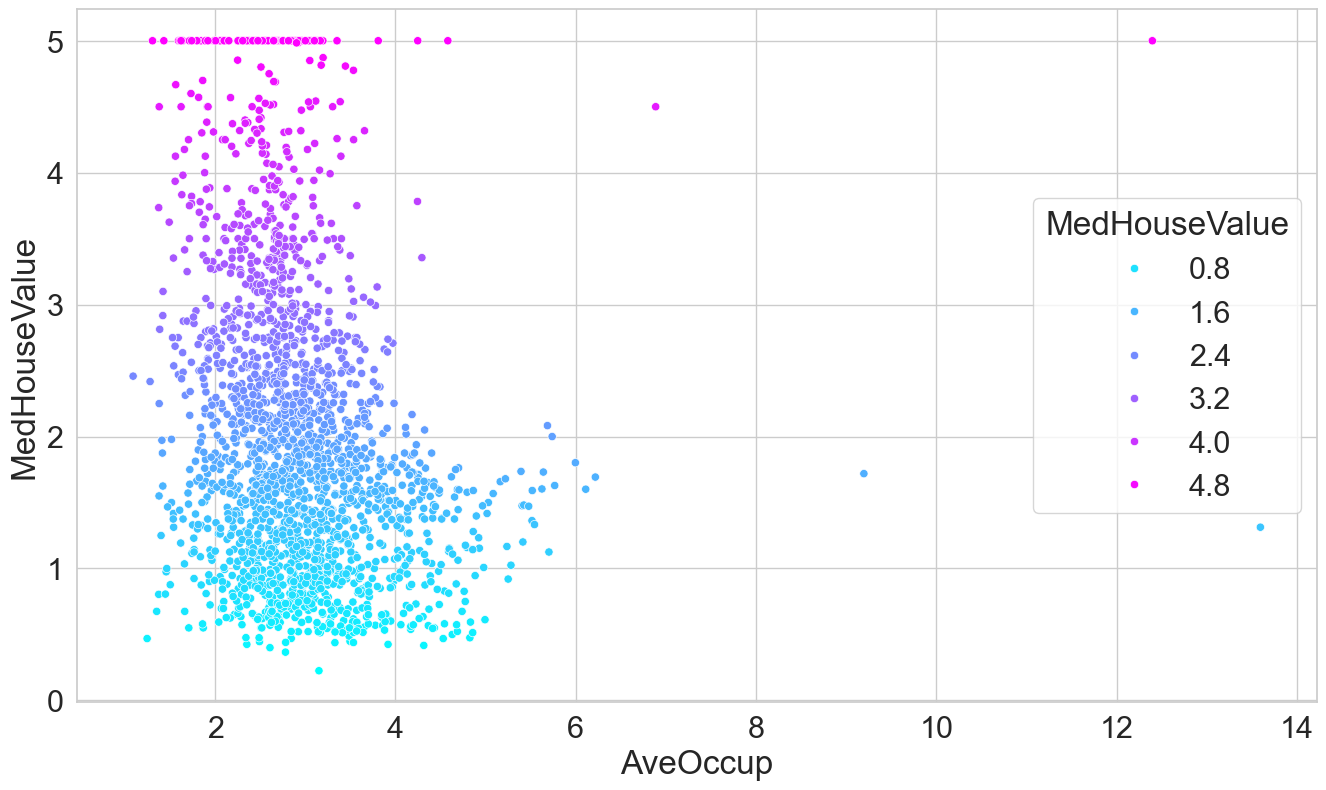

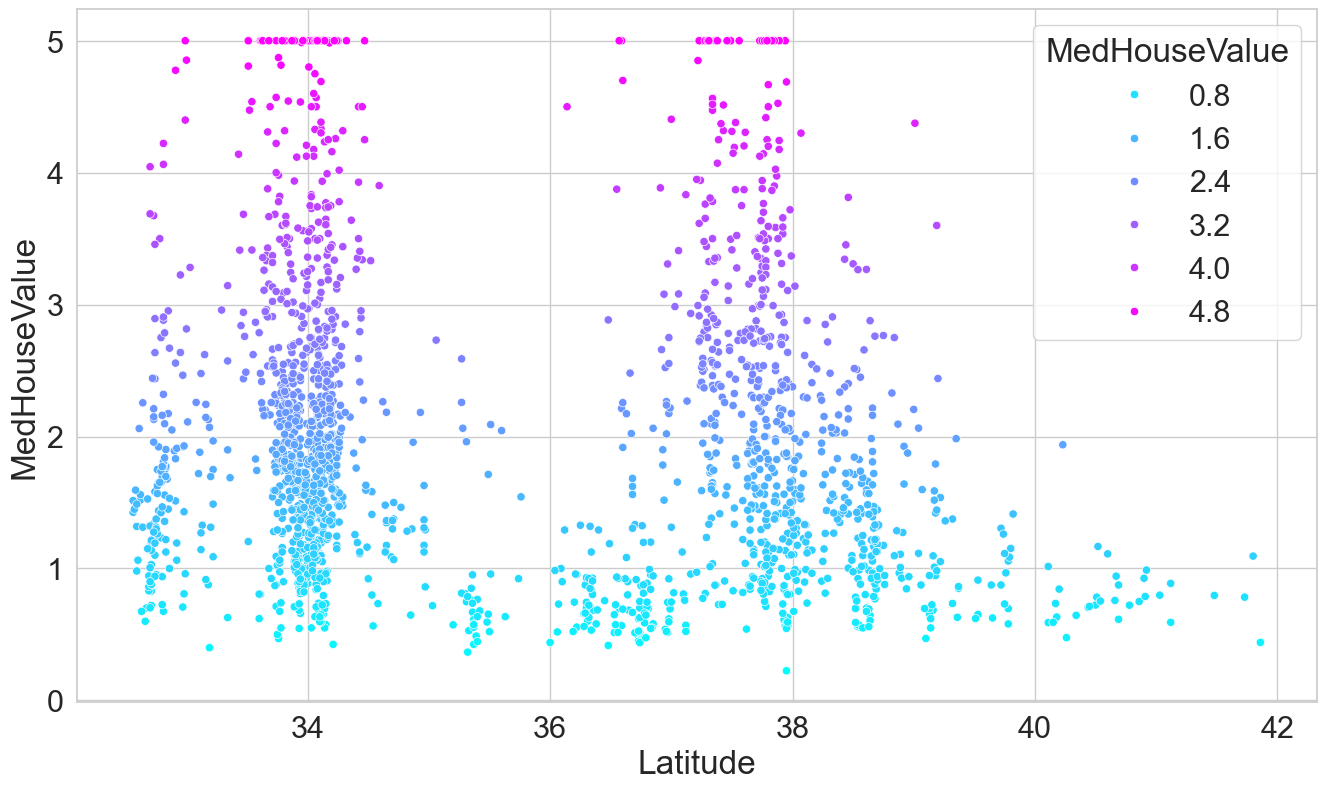

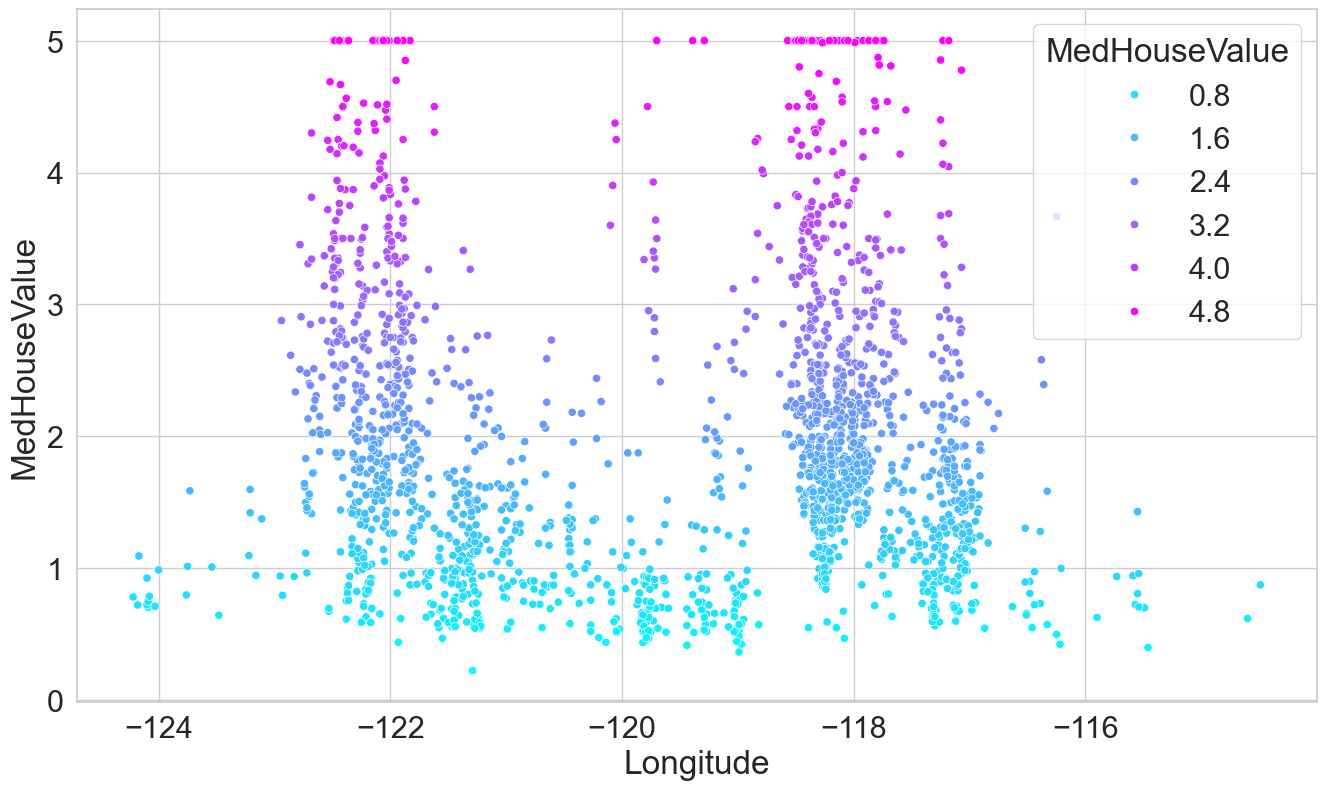

In [58]:
sns.set(font_scale = 2)
sns.set_style('whitegrid')
for feature in california.feature_names:
    plt.figure(figsize = (16, 9))
    sns.scatterplot(data = sample_df, x = feature, y = 'MedHouseValue', hue = 'MedHouseValue' ,palette = 'cool')

In [60]:
data = california.data
target = california.target
X_train, X_test, y_train, y_test = train_test_split(data, target, random_state = 11)
print(X_train.shape)
print(X_test.shape)

(15480, 8)
(5160, 8)


In [77]:
from sklearn.linear_model import LinearRegression 
LR = LinearRegression()
LR.fit(X_train, y_train)

for i,name in enumerate(california.feature_names):
    print(f'{name:>10}: {linear_regression.coef_[i]}')

    MedInc: 0.43770302153822116
  HouseAge: 0.009216834565797982
  AveRooms: -0.10732526637361
 AveBedrms: 0.6117133073918098
Population: -5.756822009291086e-06
  AveOccup: -0.0033845664657164375
  Latitude: -0.41948186096490647
 Longitude: -0.43377133498740145


In [78]:
print(linear_regression.intercept_)

-36.88295065605549


In [81]:
predicted = LR.predict(X_test)
expected = y_test

In [82]:
predicted

array([1.25396876, 2.34693107, 2.03794745, ..., 1.41376537, 1.26616891,
       1.86492088])

In [83]:
expected

array([0.762, 1.732, 1.125, ..., 0.7  , 0.866, 0.508])

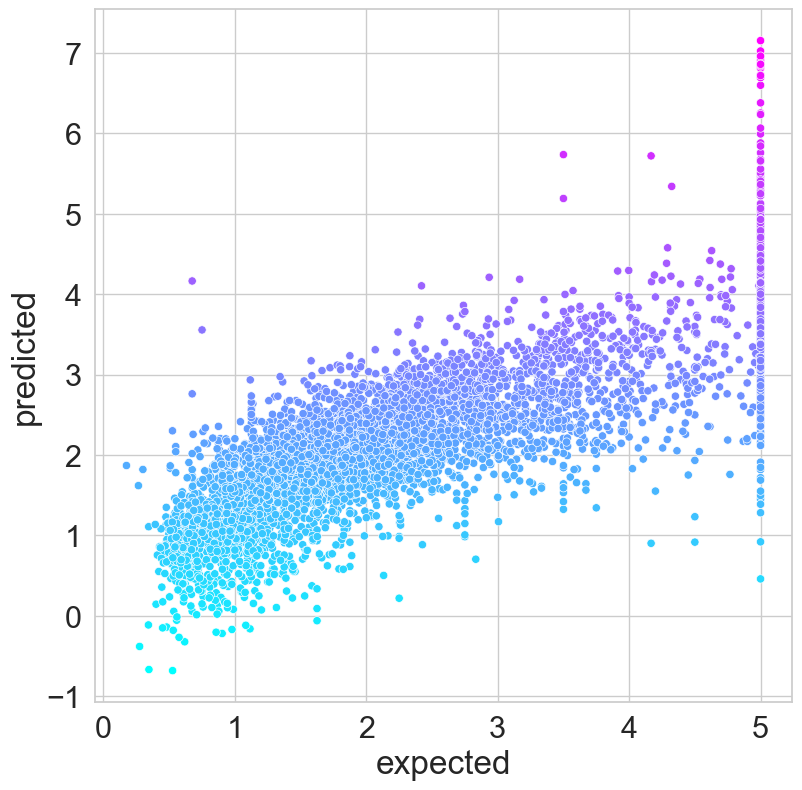

In [86]:
df = pd.DataFrame()
df['expected'] = pd.Series(expected)
df['predicted'] = pd.Series(predicted)

figure = plt.figure(figsize=(9, 9))
axes = sns.scatterplot(data=df, x='expected', y='predicted',
                       hue='predicted', palette='cool', legend=False)

In [88]:
start = min(expected.min(), predicted.min())
end = max(expected.max(), predicted.max())

print(f'X-limit {axes.set_xlim(start, end)}')
print(f'Y-limit {axes.set_ylim(start, end)}')

X-limit (-0.6830978604144562, 7.155719818496827)
Y-limit (-0.6830978604144562, 7.155719818496827)


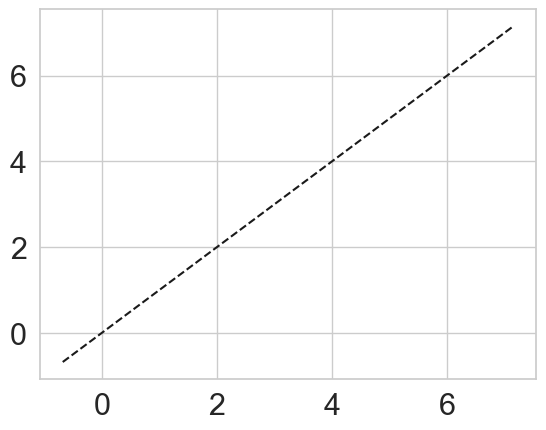

In [89]:
line = plt.plot([start, end], [start, end], 'k--')

In [90]:
from sklearn import metrics
print(f'The R2 score: {metrics.r2_score(expected, predicted)}\n')
print(f'The MSE: {metrics.mean_squared_error(expected, predicted)}')

The R2 score: 0.6008983115964329

The MSE: 0.5350149774449122


In [91]:
#choosing the best model
from sklearn.linear_model import ElasticNet, Lasso, Ridge

estimators = {
    'LinearRegression': linear_regression,
    'ElasticNet': ElasticNet(),
    'Lasso': Lasso(),
    'Ridge': Ridge()}

from sklearn.model_selection import KFold, cross_val_score

for estimator_name, estimator_object in estimators.items():
    kfold = KFold(n_splits=10, random_state=11, shuffle=True)
    scores = cross_val_score(estimator=estimator_object,
                             X=california.data, y=california.target, cv=kfold,
                             scoring='r2')
    print(f'{estimator_name:>16}: ' +
          f'mean of r2 scores={scores.mean():.3f}')

LinearRegression: mean of r2 scores=0.599
      ElasticNet: mean of r2 scores=0.423
           Lasso: mean of r2 scores=0.285
           Ridge: mean of r2 scores=0.599


In [107]:
# Decision trees

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# data
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
model = DecisionTreeRegressor(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# evaluate
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

MSE: 0.5245146178314735
Train shape: (16512, 8)
Test shape : (4128, 8)
